In [1]:
words=open('names.txt','r').read().splitlines()


In [2]:
import numpy as np

In [3]:
words

['isabella',
 'newton',
 'plank',
 'prince',
 'pravas',
 'saksham',
 'roman',
 'rabin',
 'ritesh',
 'pratyush',
 'ritika',
 'nischal',
 'animesh',
 'sabin',
 'sanjiv',
 'sunil']

In [4]:
for w in words[:5]:
    for c1,c2 in zip(w,w[1:]):
        print(c1,c2)
# everything is good but we have no idea which letter is teh starting word which is vey important for me :)))

i s
s a
a b
b e
e l
l l
l a
n e
e w
w t
t o
o n
p l
l a
a n
n k
p r
r i
i n
n c
c e
p r
r a
a v
v a
a s


In [5]:
b={}
for w in words:
    ws0=['<S>']+list(w)+['<E>']
# for every word you get do one thing , add s and e at the end so that i know it
    
    for c1,c2 in zip(ws0,ws0[1:]):
        bigram=(c1,c2)
        b[bigram]=b.get(bigram,0)+1
        # print(c1,c2)

In [6]:
sorted(b.items(),key= lambda x:x[1],reverse=True)

[(('s', 'a'), 4),
 (('n', '<E>'), 4),
 (('<S>', 'p'), 4),
 (('a', 'n'), 4),
 (('<S>', 's'), 4),
 (('s', 'h'), 4),
 (('<S>', 'r'), 4),
 (('a', 'b'), 3),
 (('p', 'r'), 3),
 (('r', 'i'), 3),
 (('i', 'n'), 3),
 (('r', 'a'), 3),
 (('h', '<E>'), 3),
 (('n', 'i'), 3),
 (('i', 's'), 2),
 (('l', 'a'), 2),
 (('a', '<E>'), 2),
 (('<S>', 'n'), 2),
 (('h', 'a'), 2),
 (('b', 'i'), 2),
 (('i', 't'), 2),
 (('e', 's'), 2),
 (('l', '<E>'), 2),
 (('<S>', 'i'), 1),
 (('b', 'e'), 1),
 (('e', 'l'), 1),
 (('l', 'l'), 1),
 (('n', 'e'), 1),
 (('e', 'w'), 1),
 (('w', 't'), 1),
 (('t', 'o'), 1),
 (('o', 'n'), 1),
 (('p', 'l'), 1),
 (('n', 'k'), 1),
 (('k', '<E>'), 1),
 (('n', 'c'), 1),
 (('c', 'e'), 1),
 (('e', '<E>'), 1),
 (('a', 'v'), 1),
 (('v', 'a'), 1),
 (('a', 's'), 1),
 (('s', '<E>'), 1),
 (('a', 'k'), 1),
 (('k', 's'), 1),
 (('a', 'm'), 1),
 (('m', '<E>'), 1),
 (('r', 'o'), 1),
 (('o', 'm'), 1),
 (('m', 'a'), 1),
 (('t', 'e'), 1),
 (('a', 't'), 1),
 (('t', 'y'), 1),
 (('y', 'u'), 1),
 (('u', 's'), 1),
 (

In [7]:
# lets make a 2d array for this
import torch

In [8]:
N=torch.zeros((28,28),dtype=torch.int32)

In [15]:
chars=sorted(list(set(''.join(words))))
chtoi={c:i for i,c in enumerate(chars)}

chtoi ['<S>'] = 26
chtoi['<E>'] = 27

itoc = {v:k for k,v in chtoi.items()}


In [16]:
b={}
for w in words:
    ws0=['<S>']+list(w)+['<E>']
# for every word you get do one thing , add s and e at the end so that i know it
    
    for c1,c2 in zip(ws0,ws0[1:]):
        ix1 = chtoi[c1]
        ix2 = chtoi[c2]

        N[ix1,ix2] += 1
        # print(c1,c2)

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

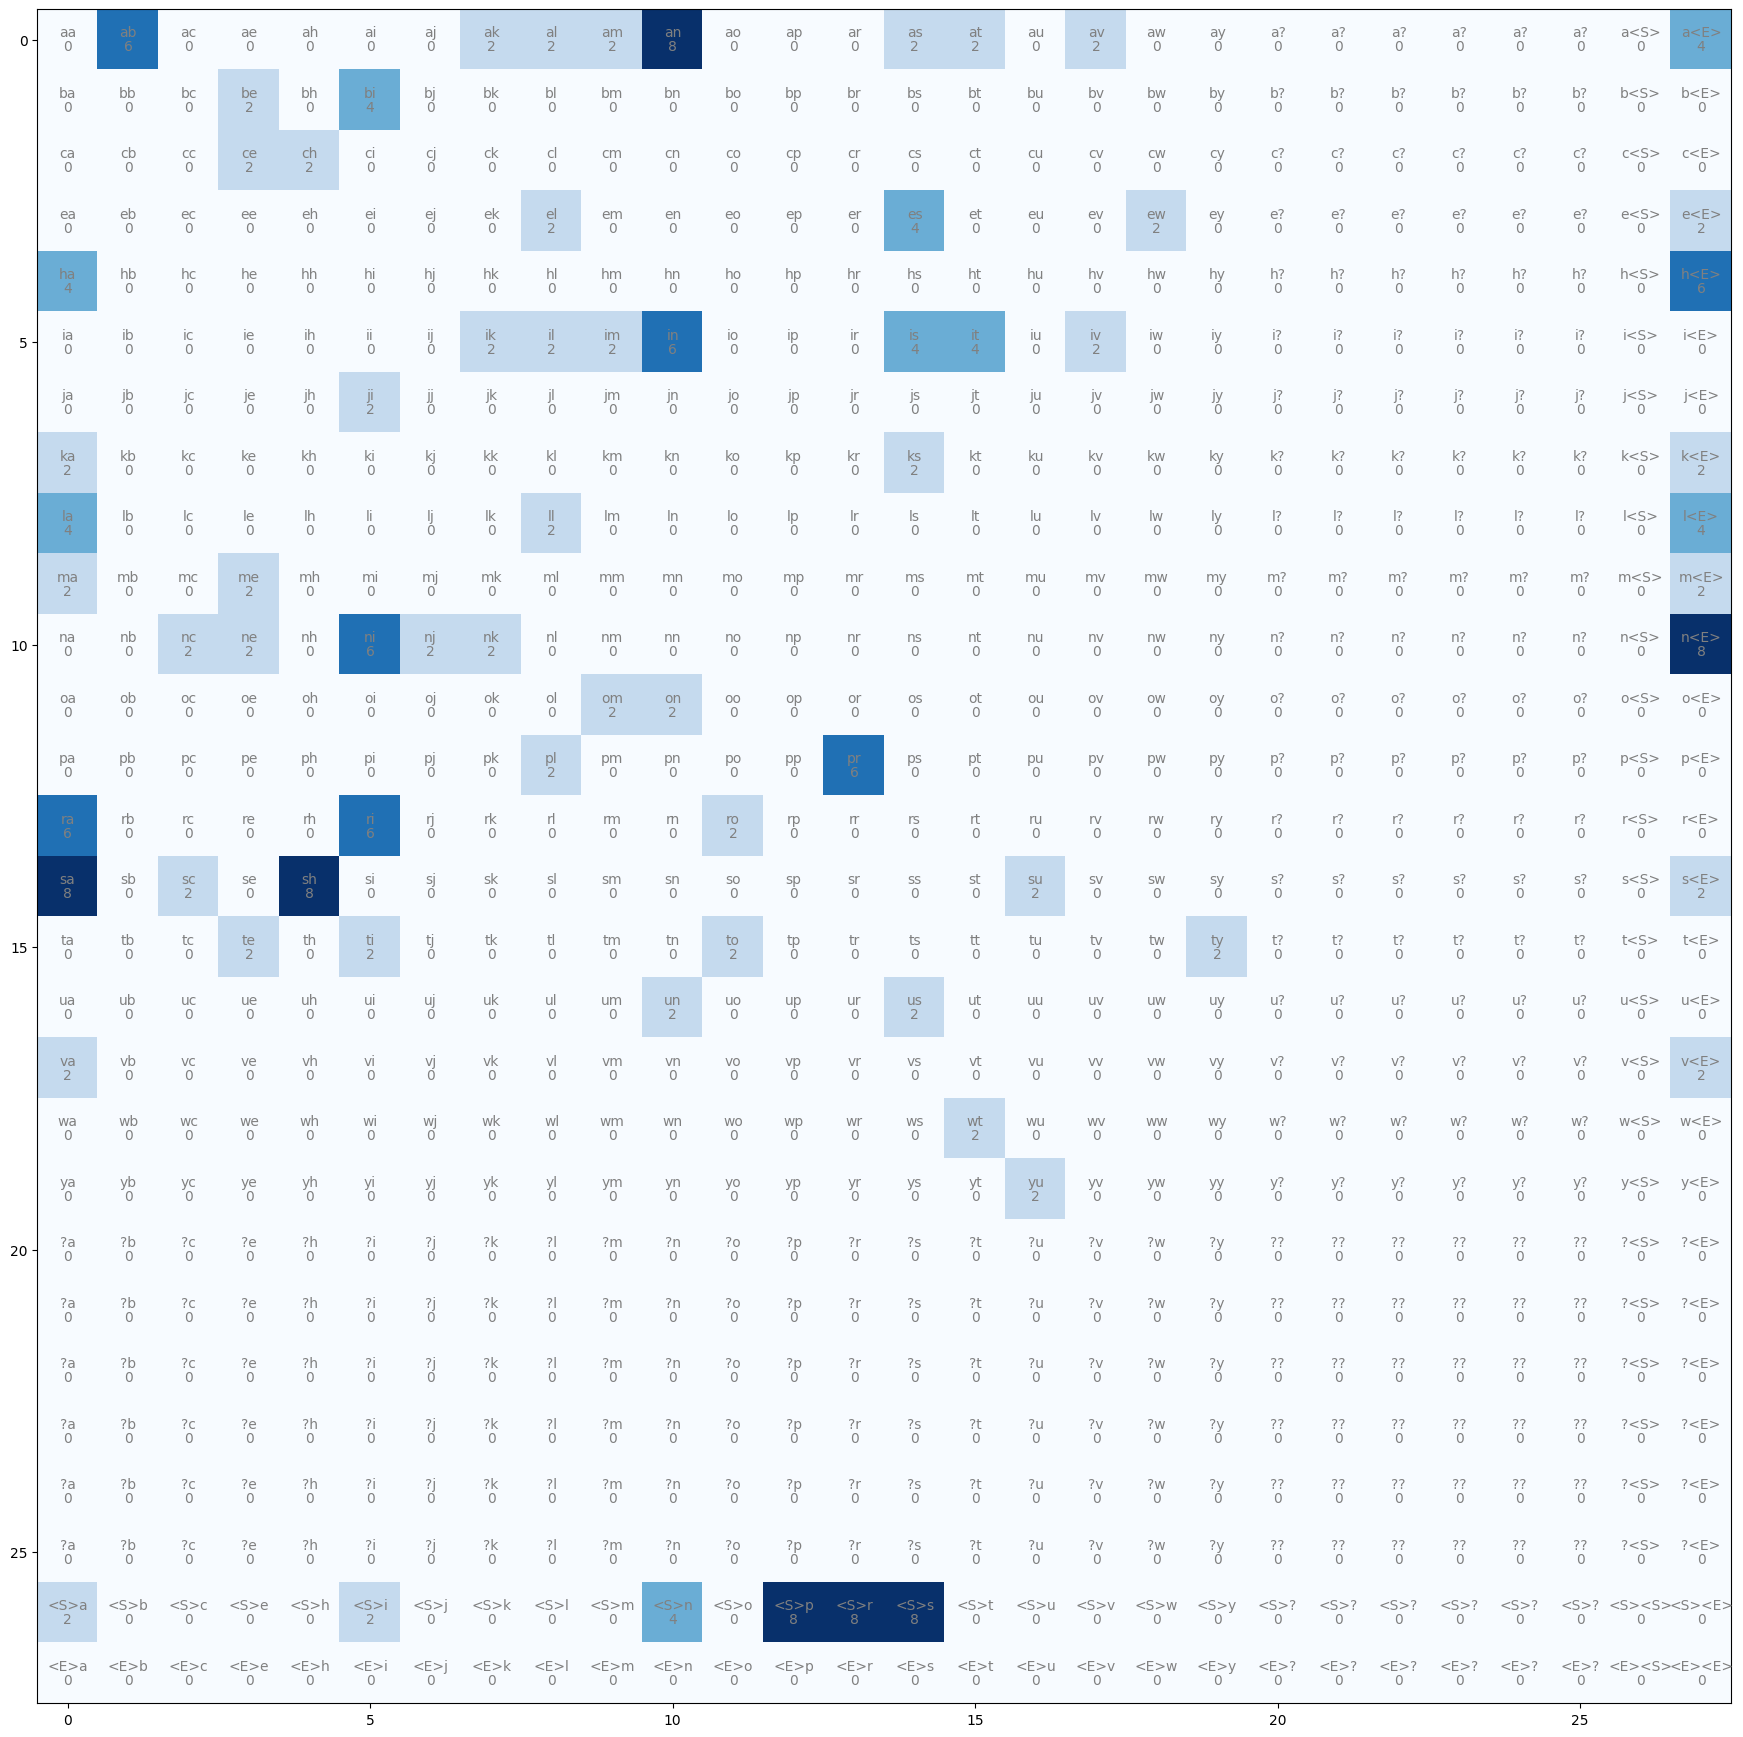

In [24]:
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize = (22,22))
plt.imshow(N, cmap = 'Blues')
for i in range (28):
    for j in range(28):
        chrstr = itoc.get(i, '?') + itoc.get(j, '?')
        plt.text(j,i, chrstr, va="bottom",color = 'gray',ha = 'center')
        plt.text(j,i, N[i,j].item(), ha="center",va = "top",color = 'gray')
plt.axes('off')

'2.4.6'